# Solución Numérica de una Ecuación Diferencial de Segundo Orden

**Método:** Runge-Kutta de segundo orden (RK2)  
**Autor:** Andres Felipe Suarez Reyes 
**Fecha:** 24/04/2026

## 1. Planteamiento del problema

Se desea resolver la ecuación diferencial de segundo orden:

$$
3y'' + 2y' + 5y = e^{-x}
$$

con las condiciones iniciales:

$$
y(0) = 5, \quad y'(0) = 7
$$

El objetivo es obtener una solución numérica utilizando el método de Runge-Kutta de segundo orden (RK2) y compararla con la solución exacta.

## 2. Conversión a sistema de primer orden

Para aplicar métodos numéricos, la ecuación se transforma en un sistema de primer orden:

Definiendo:

$$
z = \frac{dy}{dx}
$$

se obtiene el sistema:

$$
\frac{dy}{dx} = z
$$

$$
\frac{dz}{dx} = \frac{1}{3}(e^{-x} - 2z - 5y)
$$

## 3. Solución exacta

La solución exacta de la ecuación diferencial, obtenida mediante Wolfram Alpha, es:

$$
y(x) = \frac{1}{42} e^{-x} \left( 7 + 203 e^{\frac{2x}{3}} \cos\left(\frac{\sqrt{14}}{3}x\right) + 79 \sqrt{14} e^{\frac{2x}{3}} \sin\left(\frac{\sqrt{14}}{3}x\right) \right)
$$

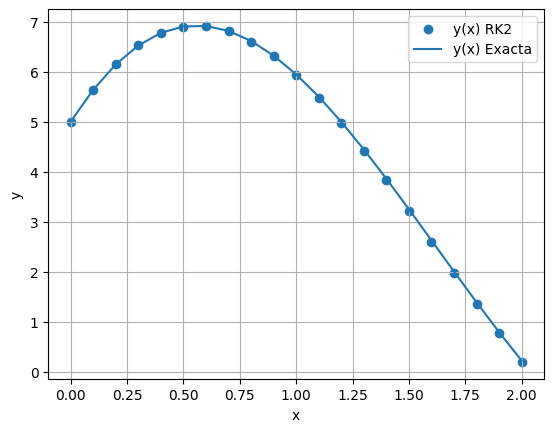

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
x0 = 0
xf = 2
N = 20
h = (xf - x0)/N

x = np.linspace(x0, xf, N+1)

# Iniciales
y = np.zeros(N+1)
z = np.zeros(N+1)

y[0] = 5
z[0] = 7

# Sistema
def f1(x, y, z):
    return z

def f2(x, y, z):
    return (np.exp(-x) - 2*z - 5*y)/3

# RK2 (Heun)
for i in range(N):
    
    k1 = f1(x[i], y[i], z[i])
    l1 = f2(x[i], y[i], z[i])
    
    k2 = f1(x[i] + h, y[i] + h*k1, z[i] + h*l1)
    l2 = f2(x[i] + h, y[i] + h*k1, z[i] + h*l1)
    
    y[i+1] = y[i] + (h/2)*(k1 + k2)
    z[i+1] = z[i] + (h/2)*(l1 + l2)
def y_exact(x):
    return (1/42)*np.exp(-x)*(
        7 
        + 203*np.exp(2*x/3)*np.cos(np.sqrt(14)*x/3)
        + 79*np.sqrt(14)*np.exp(2*x/3)*np.sin(np.sqrt(14)*x/3)
    )
# Gráfica
plt.scatter(x, y, label="y(x) RK2")
plt.plot(x, y_exact(x), label="y(x) Exacta")

plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()